In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# ============================================================
# CELL 1: Setup, Configuration & Data Preparation
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA

import copy, os, math, warnings
warnings.filterwarnings("ignore")

# ── Aesthetic defaults for all plots ─────────────────────────
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 130, "axes.titleweight": "bold"})

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Setup] Device: {device}")

# ═════════════════════════════════════════════════════════════
# GLOBAL CONFIG — change only these to re-run the experiment
# ═════════════════════════════════════════════════════════════
FORGET_CLASS   = 0          # CIFAR-10 class index to erase ("airplane")
NUM_CLASSES    = 10
BATCH_SIZE     = 128
TRAIN_EPOCHS   = 100        # used for both Baseline & Gold Standard
LR_TRAIN       = 0.1       # SGD initial LR
LR_UNLEARN     = 1e-4       # Adam LR for unlearning loop
UNLEARN_EPOCHS = 10

# Unlearning loss weights (see Lunlearn formula)
ALPHA      = 1.0    # − α · CE(forget)          → gradient ascent on forget set
BETA       = 0.5    # + β · KL(p ‖ Uniform)     → push outputs toward max entropy
LAMBDA_REG = 100.0  # + λ · Σ F_i(θ_i − θ*_i)² → EWC-style retain protection

# Checkpoint paths
CKPT_BASELINE   = "baseline_model.pth"
CKPT_GOLD       = "gold_standard_model.pth"
CKPT_UNLEARNED  = "unlearned_model.pth"

# CIFAR-10 class names (index 0 = "airplane" is our forget class)
CLASS_NAMES = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

print(f"[Config] Forget class : {FORGET_CLASS} → '{CLASS_NAMES[FORGET_CLASS]}'")
print(f"[Config] Train epochs : {TRAIN_EPOCHS}")

# ═════════════════════════════════════════════════════════════
# DATA TRANSFORMS
# ═════════════════════════════════════════════════════════════
# CIFAR-10 channel statistics (pre-computed from training set)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

# Training transform: light augmentation to avoid overfitting
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),        # random 32×32 crop from 40×40 padded img
    transforms.RandomHorizontalFlip(p=0.5),      # horizontal mirror with 50% probability
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Test/eval transform: deterministic — no augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ═════════════════════════════════════════════════════════════
# RAW DATASETS
# ═════════════════════════════════════════════════════════════
train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=train_transform)
test_dataset_full  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform)

# ═════════════════════════════════════════════════════════════
# INDEX SPLITTING — separate forget vs retain indices
# ═════════════════════════════════════════════════════════════
def get_class_indices(dataset, target_class):
    """Return two index lists: [forget_class] and [all other classes]."""
    forget_idx = [i for i, (_, y) in enumerate(dataset) if y == target_class]
    retain_idx = [i for i, (_, y) in enumerate(dataset) if y != target_class]
    return forget_idx, retain_idx

forget_train_idx, retain_train_idx = get_class_indices(train_dataset_full, FORGET_CLASS)
forget_test_idx,  retain_test_idx  = get_class_indices(test_dataset_full,  FORGET_CLASS)

# ═════════════════════════════════════════════════════════════
# DATALOADERS
# ═════════════════════════════════════════════════════════════
def make_loader(dataset, indices, shuffle=True, batch_size=BATCH_SIZE):
    return DataLoader(
        Subset(dataset, indices),
        batch_size  = batch_size,
        shuffle     = shuffle,
        num_workers = 2,
        pin_memory  = True,   # faster CPU→GPU transfer on Kaggle
    )

# Full 10-class loader (for Baseline training & final eval)
full_train_loader = DataLoader(
    train_dataset_full, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True)

full_test_loader  = DataLoader(
    test_dataset_full, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True)

# Retain loader: 9 classes (used for Gold Standard training & Fisher computation)
retain_train_loader = make_loader(train_dataset_full, retain_train_idx, shuffle=True)
retain_test_loader  = make_loader(test_dataset_full,  retain_test_idx,  shuffle=False)

# Forget loader: 1 class (used in unlearning loop & evaluation)
forget_train_loader = make_loader(train_dataset_full, forget_train_idx, shuffle=True)
forget_test_loader  = make_loader(test_dataset_full,  forget_test_idx,  shuffle=False)

# ── Summary ───────────────────────────────────────────────────
print(f"\n[Data] Full  train : {len(train_dataset_full):,} samples")
print(f"[Data] Retain train: {len(retain_train_idx):,} samples  "
      f"({len(retain_train_idx)/len(train_dataset_full)*100:.1f}%)")
print(f"[Data] Forget train: {len(forget_train_idx):,} samples  "
      f"({len(forget_train_idx)/len(train_dataset_full)*100:.1f}%)")
print(f"[Data] Forget test : {len(forget_test_idx):,} samples")
print(f"[Data] Retain test : {len(retain_test_idx):,} samples")

[Setup] Device: cuda
[Config] Forget class : 0 → 'airplane'
[Config] Train epochs : 100


100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s] 



[Data] Full  train : 50,000 samples
[Data] Retain train: 45,000 samples  (90.0%)
[Data] Forget train: 5,000 samples  (10.0%)
[Data] Forget test : 1,000 samples
[Data] Retain test : 9,000 samples


[Model] ResNet-18 CIFAR output shape: torch.Size([4, 10])
[Model] Total parameters: 11,173,962

  Training: Baseline  (100 epochs)
  Epoch   1/100  |  Train Loss: 1.8120  Acc: 40.64%  |  Test  Loss: 1.3731  Acc: 51.41%  |  LR: 0.09998  ★ best
  Epoch  10/100  |  Train Loss: 0.8353  Acc: 85.49%  |  Test  Loss: 0.6139  Acc: 81.65%  |  LR: 0.09755  
  Epoch  20/100  |  Train Loss: 0.7627  Acc: 88.71%  |  Test  Loss: 0.5964  Acc: 81.57%  |  LR: 0.09045  
  Epoch  30/100  |  Train Loss: 0.7245  Acc: 90.44%  |  Test  Loss: 0.4804  Acc: 86.22%  |  LR: 0.07939  
  Epoch  40/100  |  Train Loss: 0.6949  Acc: 91.59%  |  Test  Loss: 0.4242  Acc: 87.83%  |  LR: 0.06545  ★ best
  Epoch  50/100  |  Train Loss: 0.6565  Acc: 93.25%  |  Test  Loss: 0.4522  Acc: 86.83%  |  LR: 0.05000  
  Epoch  60/100  |  Train Loss: 0.6140  Acc: 95.14%  |  Test  Loss: 0.3858  Acc: 89.41%  |  LR: 0.03455  
  Epoch  70/100  |  Train Loss: 0.5644  Acc: 97.37%  |  Test  Loss: 0.3165  Acc: 92.18%  |  LR: 0.02061  ★ best
  E

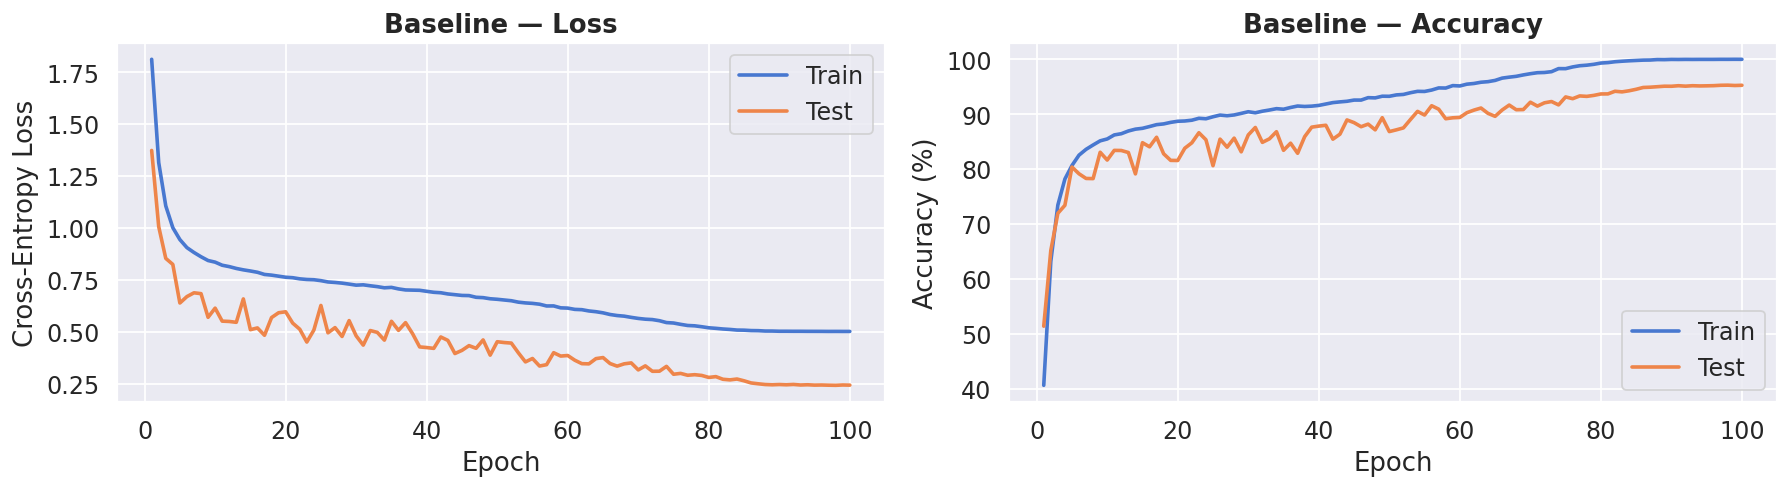


  Training: Gold Standard  (100 epochs)
  Epoch   1/100  |  Train Loss: 1.8322  Acc: 39.48%  |  Test  Loss: 1.3869  Acc: 48.70%  |  LR: 0.09998  ★ best
  Epoch  10/100  |  Train Loss: 0.8189  Acc: 86.22%  |  Test  Loss: 0.7834  Acc: 74.54%  |  LR: 0.09755  
  Epoch  20/100  |  Train Loss: 0.7463  Acc: 89.52%  |  Test  Loss: 0.5057  Acc: 84.93%  |  LR: 0.09045  
  Epoch  30/100  |  Train Loss: 0.7091  Acc: 90.89%  |  Test  Loss: 0.4309  Acc: 87.91%  |  LR: 0.07939  ★ best
  Epoch  40/100  |  Train Loss: 0.6751  Acc: 92.54%  |  Test  Loss: 0.5015  Acc: 85.48%  |  LR: 0.06545  
  Epoch  50/100  |  Train Loss: 0.6416  Acc: 93.88%  |  Test  Loss: 0.3864  Acc: 89.24%  |  LR: 0.05000  
  Epoch  60/100  |  Train Loss: 0.6030  Acc: 95.69%  |  Test  Loss: 0.3576  Acc: 90.71%  |  LR: 0.03455  
  Epoch  70/100  |  Train Loss: 0.5588  Acc: 97.56%  |  Test  Loss: 0.3348  Acc: 91.64%  |  LR: 0.02061  
  Epoch  80/100  |  Train Loss: 0.5192  Acc: 99.25%  |  Test  Loss: 0.2791  Acc: 93.93%  |  LR: 0.0

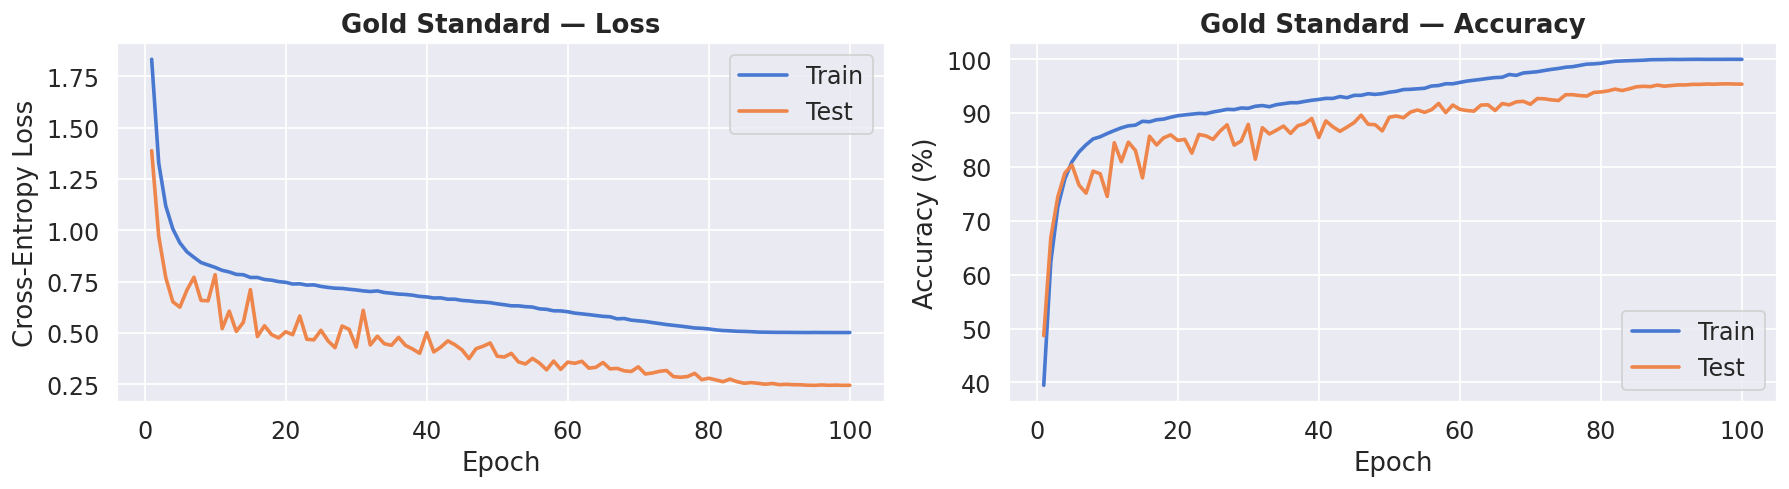

In [6]:
# ============================================================
# CELL 2: Model Definition & Standard Training Loop
# ============================================================

# ═════════════════════════════════════════════════════════════
# RESNET-18 FOR CIFAR-10
# ═════════════════════════════════════════════════════════════
def build_resnet18_cifar(num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    ResNet-18 adapted for 32×32 CIFAR images.

    Two key changes from the standard ImageNet version:
      1. conv1: kernel 3×3, stride 1, no padding=3 → preserves spatial resolution
                (ImageNet uses 7×7 stride-2 which would crush 32×32 to 8×8 immediately)
      2. maxpool removed → again, avoids excessive downsampling on small inputs

    This is the canonical CIFAR ResNet adaptation used in the original
    He et al. 2015 paper for CIFAR-10 experiments.
    """
    model = models.resnet18(weights=None)

    # Replace first conv: 7×7 s2 → 3×3 s1, no early downsampling
    model.conv1 = nn.Conv2d(
        in_channels  = 3,
        out_channels = 64,
        kernel_size  = 3,
        stride       = 1,
        padding      = 1,
        bias         = False,
    )
    # Remove the max-pool layer (it halves resolution from 32→16 unnecessarily)
    model.maxpool = nn.Identity()

    # Replace final FC for the correct number of classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


# Sanity check the output shape
_dummy = torch.randn(4, 3, 32, 32)
_out   = build_resnet18_cifar()(_dummy)
print(f"[Model] ResNet-18 CIFAR output shape: {_out.shape}")   # expect (4, 10)
total_params = sum(p.numel() for p in build_resnet18_cifar().parameters())
print(f"[Model] Total parameters: {total_params:,}")


# ═════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ═════════════════════════════════════════════════════════════
def train_one_epoch(model, loader, optimizer, criterion, device):
    """One full pass over the training loader. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = correct = total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)   # slightly faster than zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping: prevents exploding gradients during early epochs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct      += (logits.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate model on a DataLoader. Returns (avg_loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss = correct = total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        correct      += (logits.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, 100.0 * correct / total


# ═════════════════════════════════════════════════════════════
# MAIN TRAINING FUNCTION (Baseline & Gold Standard share this)
# ═════════════════════════════════════════════════════════════
def train_model(model_name:   str,
                train_loader: DataLoader,
                test_loader:  DataLoader,
                save_path:    str,
                epochs:       int   = TRAIN_EPOCHS,
                lr:           float = LR_TRAIN) -> nn.Module:
    """
    Full training pipeline with:
      • SGD + momentum + weight-decay (standard CIFAR recipe)
      • CosineAnnealingLR scheduler (smoother than step decay)
      • Best-checkpoint saving based on test accuracy

    Args:
        model_name   : label for print statements ("Baseline" / "Gold Standard")
        train_loader : DataLoader for training data
        test_loader  : DataLoader for validation/test data
        save_path    : where to save the best .pth checkpoint
        epochs       : number of training epochs
        lr           : initial learning rate

    Returns:
        model with best test-accuracy weights loaded
    """
    model = build_resnet18_cifar().to(device)

    # SGD with Nesterov momentum — standard recipe for CIFAR ResNet training
    optimizer = optim.SGD(
        model.parameters(),
        lr           = lr,
        momentum     = 0.9,
        weight_decay = 5e-4,
        nesterov     = True,
    )

    # Cosine annealing: smoothly reduces LR from `lr` → 0 over `epochs`
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # label_smoothing=0.1: prevents the model from becoming overconfident,
    # which improves calibration — important for the KL analysis later.

    best_acc  = 0.0
    history   = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}  ({epochs} epochs)")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        # Save checkpoint whenever test accuracy improves
        if te_acc > best_acc:
            best_acc = te_acc
            torch.save(model.state_dict(), save_path)

        # Print progress every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  |  "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%  |  "
                  f"Test  Loss: {te_loss:.4f}  Acc: {te_acc:.2f}%  |  "
                  f"LR: {scheduler.get_last_lr()[0]:.5f}  "
                  f"{'★ best' if te_acc == best_acc else ''}")

    print(f"\n  ✓ {model_name} best test accuracy: {best_acc:.2f}%")
    print(f"  ✓ Checkpoint saved → {save_path}")

    # ── Plot training curves ──────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = range(1, epochs + 1)

    ax1.plot(epochs_range, history["train_loss"], label="Train", lw=2)
    ax1.plot(epochs_range, history["test_loss"],  label="Test",  lw=2)
    ax1.set(title=f"{model_name} — Loss", xlabel="Epoch", ylabel="Cross-Entropy Loss")
    ax1.legend()

    ax2.plot(epochs_range, history["train_acc"], label="Train", lw=2)
    ax2.plot(epochs_range, history["test_acc"],  label="Test",  lw=2)
    ax2.set(title=f"{model_name} — Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{model_name.lower().replace(' ','_')}_training_curve.png",
                bbox_inches="tight")
    plt.show()

    # Load the best-checkpoint weights before returning
    model.load_state_dict(torch.load(save_path, map_location=device))
    return model


# ═════════════════════════════════════════════════════════════
# RUN TRAINING
# ═════════════════════════════════════════════════════════════

# ── Baseline: trained on ALL 10 classes ──────────────────────
baseline_model = train_model(
    model_name   = "Baseline",
    train_loader = full_train_loader,
    test_loader  = full_test_loader,
    save_path    = CKPT_BASELINE,
)

# ── Gold Standard: trained from scratch on 9 retain classes ──
# This is the theoretical upper-bound for unlearning quality.
# A perfect unlearning algorithm should produce a model whose
# behaviour is indistinguishable from this one.
gold_model = train_model(
    model_name   = "Gold Standard",
    train_loader = retain_train_loader,
    test_loader  = retain_test_loader,
    save_path    = CKPT_GOLD,
)


[Unlearn] Loading baseline checkpoint …

[Unlearn] Computing diagonal Fisher Information …
[Fisher] Processed 12,800 retain samples (100 batches)
[Fisher] Total accumulated Fisher mass: 2.3234
[Fisher] Top-5 layers by mean |F|:
  layer4.1.bn1.weight                            0.00025626
  layer4.1.bn1.bias                              0.00011848
  fc.bias                                        0.00001775
  layer4.1.bn2.weight                            0.00001495
  layer4.0.bn2.weight                            0.00001171

  Unlearning  (α=1.0, β=0.5, λ=100.0)
  Epoch  1/10  |  Total: -3.6175  |  CE↑: 4.2414  |  KL→U: 1.2474  |  Fisher: 0.0000
  Epoch  2/10  |  Total: -4.6578  |  CE↑: 5.4341  |  KL→U: 1.5517  |  Fisher: 0.0000
  Epoch  3/10  |  Total: -5.4380  |  CE↑: 6.3862  |  KL→U: 1.8947  |  Fisher: 0.0000
  Epoch  4/10  |  Total: -6.2020  |  CE↑: 7.3097  |  KL→U: 2.2128  |  Fisher: 0.0000
  Epoch  5/10  |  Total: -7.0395  |  CE↑: 8.3384  |  KL→U: 2.5939  |  Fisher: 0.0000
  Epoch

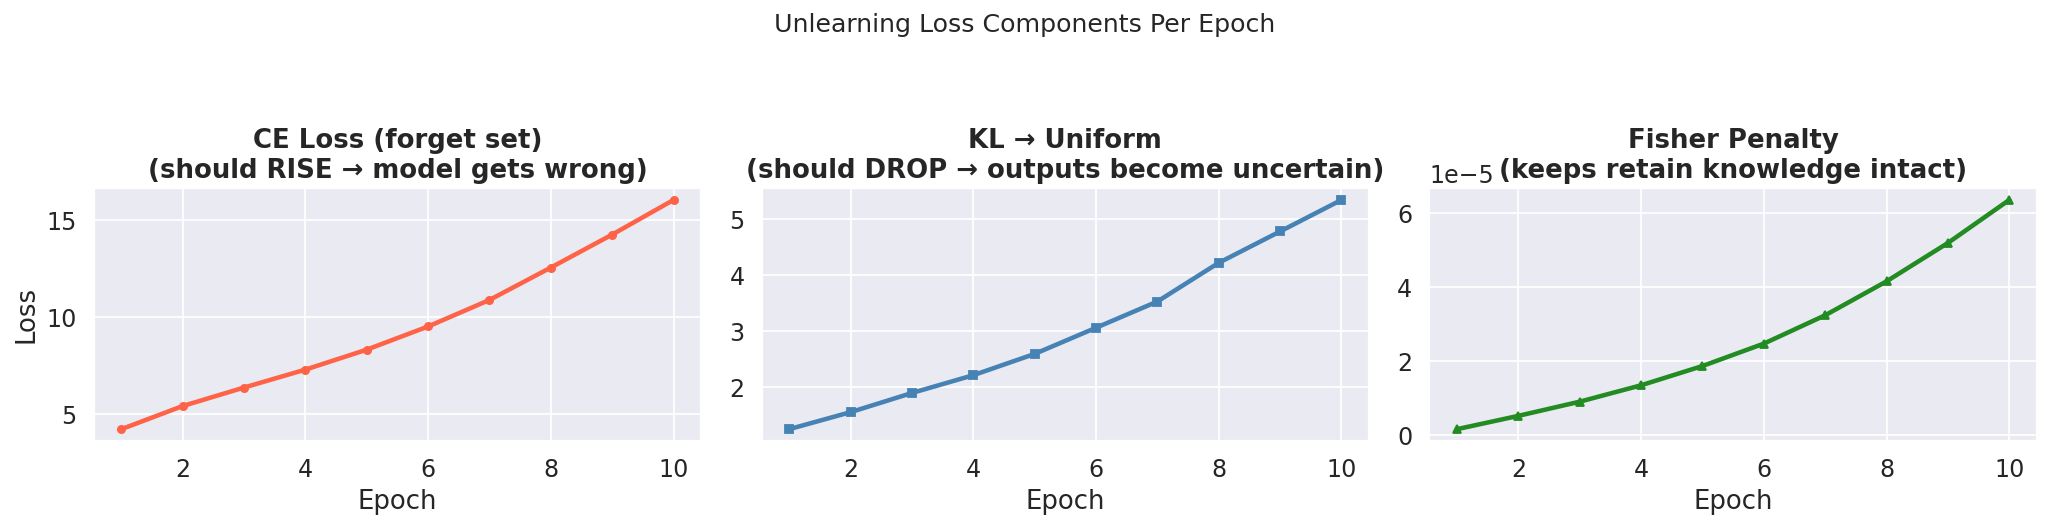


[Unlearn] ✓ Unlearned model saved → unlearned_model.pth


In [9]:
# ============================================================
# CELL 3: Fisher Information Computation & Unlearning Loop
# ============================================================

# ═════════════════════════════════════════════════════════════
# 3-A  DIAGONAL FISHER INFORMATION MATRIX
# ═════════════════════════════════════════════════════════════
def compute_diagonal_fisher(model:        nn.Module,
                            retain_loader: DataLoader,
                            device:        torch.device,
                            max_batches:   int = 100) -> dict:
    """
    Computes the diagonal of the Empirical Fisher Information Matrix (FIM):

        F_i  =  E_{(x,y) ~ D_retain} [ ( ∂ log p_θ(y|x) / ∂θ_i )² ]

    Intuition
    ─────────
    • F_i is large  → parameter θ_i is CRUCIAL for retain-set predictions.
      The EWC regulariser will heavily penalise any change to it during
      unlearning → retain-class knowledge is protected.
    • F_i is small  → parameter θ_i barely affects retain-set outputs.
      It can drift freely → forget-class information can be erased there.

    Why diagonal?
    The full FIM is an n×n matrix (n = number of parameters in ResNet-18
    ≈ 11 million → 121 trillion entries).  The diagonal approximation
    (one scalar per parameter) is standard practice (EWC, SI, MAS).

    Args:
        model        : pre-trained model (must already be on `device`)
        retain_loader: DataLoader for retain classes (classes 1-9)
        device       : torch device
        max_batches  : cap to control runtime (100 batches ≈ 12,800 samples)

    Returns:
        fisher_dict  : { param_name → tensor of same shape, values = F_i }
    """
    model.eval()

    # Initialise accumulators: same shape as each parameter, filled with zeros
    fisher_dict = {
        name: torch.zeros_like(param)
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    n_samples = 0

    for batch_idx, (imgs, labels) in enumerate(retain_loader):
        if batch_idx >= max_batches:
            break

        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)
        n_samples += B

        model.zero_grad()

        logits    = model(imgs)                               # (B, 10)
        log_probs = F.log_softmax(logits, dim=1)              # log p_θ(y|x)

        # Negative log-likelihood of the true label: −log p_θ(y_i | x_i)
        # We average over the batch to get the expected NLL
        nll = -log_probs[torch.arange(B), labels].mean()

        # Backward: computes ∂nll/∂θ_i for every parameter
        nll.backward()

        # Accumulate squared gradients, weighted by batch size
        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    fisher_dict[name] += (param.grad.detach() ** 2) * B

    # Normalise by total samples → unbiased estimate of E[grad²]
    with torch.no_grad():
        for name in fisher_dict:
            fisher_dict[name] /= max(n_samples, 1)

    model.zero_grad()

    # ── Diagnostic print ──────────────────────────────────────
    print(f"[Fisher] Processed {n_samples:,} retain samples "
          f"({min(max_batches, len(retain_loader))} batches)")
    total_fisher = sum(f.sum().item() for f in fisher_dict.values())
    print(f"[Fisher] Total accumulated Fisher mass: {total_fisher:.4f}")

    # Show the top-5 layers by mean Fisher magnitude
    layer_means = {k: v.mean().item() for k, v in fisher_dict.items()}
    top5 = sorted(layer_means.items(), key=lambda x: -x[1])[:5]
    print("[Fisher] Top-5 layers by mean |F|:")
    for name, val in top5:
        print(f"  {name:<45s}  {val:.8f}")

    return fisher_dict


# ═════════════════════════════════════════════════════════════
# 3-B  FISHER-REGULARISED GRADIENT ASCENT UNLEARNING LOOP
# ═════════════════════════════════════════════════════════════
def unlearn_model(model:                 nn.Module,
                  original_frozen_model: nn.Module,
                  forget_loader:         DataLoader,
                  fisher_dict:           dict,
                  alpha:       float = ALPHA,
                  beta:        float = BETA,
                  lambda_reg:  float = LAMBDA_REG,
                  epochs:      int   = UNLEARN_EPOCHS,
                  lr:          float = LR_UNLEARN) -> nn.Module:
    """
    Applies the 3-term unlearning loss:

        L_unlearn = −α · L_CE(forget)                    [Term 1]
                  +  β · KL( p_θ(y|x)  ‖  Uniform(10) ) [Term 2]
                  +  λ · Σ_i F_i · (θ_i − θ*_i)²        [Term 3]

    ── Term 1: Gradient ASCENT on forget set ─────────────────
    Standard CE is minimised (makes the model more correct).
    Negating it means we MAXIMISE CE → the model becomes WRONG
    on forget-class images.  This directly degrades forget accuracy.

    ── Term 2: KL divergence toward Uniform ──────────────────
    We want the model to output a uniform distribution (max entropy)
    on forget-class inputs — equivalent to saying "I have no idea
    what this is."  KL(p ‖ U) is minimised when p = U.
    Note: F.kl_div(log_q, p) computes KL(p ‖ q) — argument order matters!

    ── Term 3: EWC Fisher Regulariser ────────────────────────
    Prevents the unlearning from destroying retain-class knowledge.
    Parameters with high F_i (important for 9 retain classes) are
    heavily penalised if they move away from θ* (original weights).
    Parameters with low F_i (unimportant for retain classes, but
    possibly important for the forget class) can change freely.

    This is the key mechanism that makes targeted unlearning possible.
    """
    model.to(device)
    original_frozen_model.to(device)
    original_frozen_model.eval()   # θ* is frozen — never updated

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Pre-build a uniform distribution tensor once (avoid allocating each batch)
    # Shape (10,) — will be broadcast to (B, 10) inside the loop
    uniform_target = torch.full(
        (NUM_CLASSES,), fill_value=1.0 / NUM_CLASSES, device=device
    )

    # Cache original parameters as a name→tensor dict for fast lookup
    orig_params = {name: param.detach().clone()
                   for name, param in original_frozen_model.named_parameters()}

    history = {"loss": [], "ce": [], "kl": [], "fisher": []}

    print(f"\n{'='*60}")
    print(f"  Unlearning  (α={alpha}, β={beta}, λ={lambda_reg})")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = epoch_ce = epoch_kl = epoch_fisher = 0.0
        n_batches  = 0

        for imgs, labels in forget_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            B = imgs.size(0)

            optimizer.zero_grad(set_to_none=True)

            logits    = model(imgs)                        # (B, 10)
            log_probs = F.log_softmax(logits, dim=1)       # (B, 10)

            # ── Term 1: −α · CE(forget) ───────────────────
            ce_loss      = F.cross_entropy(logits, labels)
            loss_ascent  = -alpha * ce_loss   # negative = gradient ASCENT

            # ── Term 2: β · KL(p_θ ‖ Uniform) ────────────
            # Expand uniform to (B, 10) to match batch dimension
            uniform_batch = uniform_target.unsqueeze(0).expand(B, -1)
            # F.kl_div(input, target) computes Σ target * (log target − input)
            # where input must be in LOG space → we pass log_probs
            # reduction='batchmean' divides by batch size (correct KL normalisation)
            kl_loss  = F.kl_div(log_probs, uniform_batch, reduction='batchmean')
            loss_kl  = beta * kl_loss

            # ── Term 3: λ · Σ F_i (θ_i − θ*_i)² ─────────
            fisher_penalty = torch.tensor(0.0, device=device)
            for name, param in model.named_parameters():
                if name in fisher_dict and name in orig_params:
                    diff    = param - orig_params[name]      # θ_i − θ*_i
                    penalty = (fisher_dict[name] * diff ** 2).sum()
                    fisher_penalty = fisher_penalty + penalty

            loss_fisher = lambda_reg * fisher_penalty

            # ── Total loss & backward ─────────────────────
            total_loss = loss_ascent + loss_kl + loss_fisher
            total_loss.backward()

            # Gradient clipping: essential for stability when doing gradient
            # ascent, as gradients can be large and destabilise training
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss   += total_loss.item()
            epoch_ce     += ce_loss.item()
            epoch_kl     += kl_loss.item()
            epoch_fisher += fisher_penalty.item()
            n_batches    += 1

        # ── Per-epoch averages ────────────────────────────
        avg = lambda x: x / max(n_batches, 1)
        history["loss"].append(avg(epoch_loss))
        history["ce"].append(avg(epoch_ce))
        history["kl"].append(avg(epoch_kl))
        history["fisher"].append(avg(epoch_fisher))

        print(f"  Epoch {epoch:2d}/{epochs}  |  "
              f"Total: {avg(epoch_loss):.4f}  |  "
              f"CE↑: {avg(epoch_ce):.4f}  |  "
              f"KL→U: {avg(epoch_kl):.4f}  |  "
              f"Fisher: {avg(epoch_fisher):.4f}")

    # ── Plot unlearning loss components ───────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ep_range  = range(1, epochs + 1)

    axes[0].plot(ep_range, history["ce"],     color="tomato",    lw=2.5, marker="o", ms=4)
    axes[0].set(title="CE Loss (forget set)\n(should RISE → model gets wrong)",
                xlabel="Epoch", ylabel="Loss")

    axes[1].plot(ep_range, history["kl"],     color="steelblue", lw=2.5, marker="s", ms=4)
    axes[1].set(title="KL → Uniform\n(should DROP → outputs become uncertain)",
                xlabel="Epoch")

    axes[2].plot(ep_range, history["fisher"], color="forestgreen", lw=2.5, marker="^", ms=4)
    axes[2].set(title="Fisher Penalty\n(keeps retain knowledge intact)",
                xlabel="Epoch")

    plt.suptitle("Unlearning Loss Components Per Epoch", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("unlearning_loss_components.png", bbox_inches="tight")
    plt.show()

    return model

# ═════════════════════════════════════════════════════════════
# 3-C  EXECUTION BLOCK  (fixed)
# ═════════════════════════════════════════════════════════════

# ── Load pre-trained Baseline weights into the model we will mutate ──
print("\n[Unlearn] Loading baseline checkpoint …")
unlearned_model = build_resnet18_cifar().to(device)
unlearned_model.load_state_dict(torch.load(CKPT_BASELINE, map_location=device))

# ── Frozen reference copy (θ*) — used ONLY for the Fisher penalty term ──
# requires_grad stays True on the live model; the frozen copy is only ever
# accessed via .detach() inside the penalty loop, so it never needs grads.
frozen_reference = copy.deepcopy(unlearned_model)
for p in frozen_reference.parameters():
    p.requires_grad_(False)   # safe here — we never call .backward() on this copy

# ── Compute Fisher on the LIVE model (grads are enabled) ─────────────
# Key fix: pass `unlearned_model`, NOT `frozen_reference`.
# Fisher computation needs backward() to work → requires_grad must be True.
print("\n[Unlearn] Computing diagonal Fisher Information …")
fisher_dict = compute_diagonal_fisher(
    model         = unlearned_model,     # ← fixed: has requires_grad=True
    retain_loader = retain_train_loader,
    device        = device,
    max_batches   = 100,
)

# ── Run the unlearning loop ───────────────────────────────────
unlearned_model = unlearn_model(
    model                 = unlearned_model,
    original_frozen_model = frozen_reference,   # θ* for EWC penalty
    forget_loader         = forget_train_loader,
    fisher_dict           = fisher_dict,
    alpha                 = ALPHA,
    beta                  = BETA,
    lambda_reg            = LAMBDA_REG,
    epochs                = UNLEARN_EPOCHS,
    lr                    = LR_UNLEARN,
)

# ── Save unlearned checkpoint ─────────────────────────────────
torch.save(unlearned_model.state_dict(), CKPT_UNLEARNED)
print(f"\n[Unlearn] ✓ Unlearned model saved → {CKPT_UNLEARNED}")

[Eval] Loading checkpoints …
[Eval] Evaluating 'Baseline' …
[Eval] Evaluating 'Gold Standard' …
[Eval] Evaluating 'Unlearned' …

════════════════════════════════════════════════════════════════════════
                      BEHAVIORAL EVALUATION TABLE                     
════════════════════════════════════════════════════════════════════════
  Metric                               Baseline     Gold Std    Unlearned
────────────────────────────────────────────────────────────────────────
  Forget Cls Accuracy  (%) ↓             95.600        0.000        0.000
  Retain Cls Accuracy  (%) ↑             95.244       95.433       21.133
  Forget Cls Entropy (nats) ↑             0.574        0.892        0.138
────────────────────────────────────────────────────────────────────────
  Max possible entropy                                              2.303
════════════════════════════════════════════════════════════════════════

  Gap (Unlearned vs Gold Standard):
    Forget accuracy gap : 0.

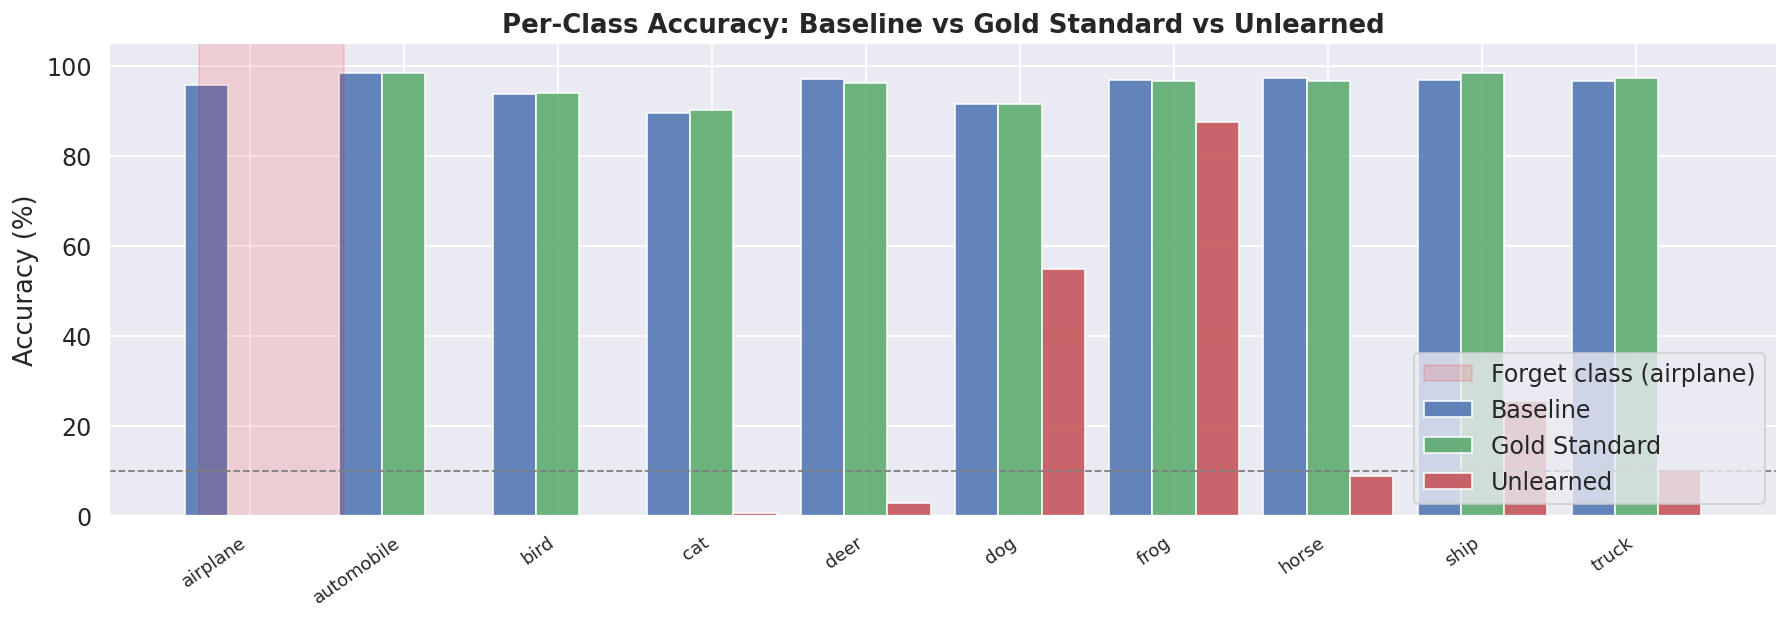

In [10]:
# ============================================================
# CELL 4: Behavioral Evaluation — 3-Model Comparison Table
# ============================================================

# ═════════════════════════════════════════════════════════════
# METRIC FUNCTIONS
# ═════════════════════════════════════════════════════════════

@torch.no_grad()
def get_class_accuracy(model: nn.Module,
                       loader: DataLoader,
                       device: torch.device) -> float:
    """Top-1 accuracy (%) on all samples in `loader`."""
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds    = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / max(total, 1)


@torch.no_grad()
def get_forget_entropy(model: nn.Module,
                       loader: DataLoader,
                       device: torch.device) -> float:
    """
    Mean Shannon entropy (nats) of the model's output distribution
    on forget-class images.

    H(p) = −Σ_k p_k · log(p_k)

    Interpretation:
      Before unlearning : entropy ≈ low   (model is confident & correct)
      After  unlearning : entropy ≈ high  (model is maximally confused)
      Perfect unlearning: H → log(10) ≈ 2.303 nats  (uniform distribution)

    The Gold Standard model has never seen the forget class during training
    so its entropy on forget images is a natural reference point.
    """
    model.eval()
    total_H = count = 0.0
    for imgs, _ in loader:
        imgs  = imgs.to(device)
        probs = F.softmax(model(imgs), dim=1)         # (B, 10)
        # Per-sample entropy: −Σ_k p_k log(p_k)
        entropy = -(probs * (probs + 1e-9).log()).sum(dim=1)  # (B,)
        total_H += entropy.sum().item()
        count   += imgs.size(0)
    return total_H / max(count, 1)


@torch.no_grad()
def get_per_class_accuracy(model: nn.Module,
                           loader: DataLoader,
                           device: torch.device,
                           num_classes: int = NUM_CLASSES) -> dict:
    """Returns a dict {class_idx: accuracy%} for per-class breakdown."""
    model.eval()
    correct = [0] * num_classes
    total   = [0] * num_classes

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        for c in range(num_classes):
            mask         = (labels == c)
            correct[c]  += (preds[mask] == labels[mask]).sum().item()
            total[c]    += mask.sum().item()

    return {c: (100.0 * correct[c] / total[c] if total[c] > 0 else float("nan"))
            for c in range(num_classes)}


# ═════════════════════════════════════════════════════════════
# LOAD ALL THREE MODELS
# ═════════════════════════════════════════════════════════════
def load_model(ckpt_path: str) -> nn.Module:
    m = build_resnet18_cifar().to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()
    return m

print("[Eval] Loading checkpoints …")
mdl_baseline  = load_model(CKPT_BASELINE)
mdl_gold      = load_model(CKPT_GOLD)
mdl_unlearned = load_model(CKPT_UNLEARNED)

models_info = [
    ("Baseline",     mdl_baseline),
    ("Gold Standard",mdl_gold),
    ("Unlearned",    mdl_unlearned),
]

# ═════════════════════════════════════════════════════════════
# COMPUTE METRICS
# ═════════════════════════════════════════════════════════════
MAX_ENTROPY = math.log(NUM_CLASSES)   # ≈ 2.303 nats (uniform distribution)

results = {}
for name, mdl in models_info:
    print(f"[Eval] Evaluating '{name}' …")
    results[name] = {
        "forget_acc"  : get_class_accuracy(mdl, forget_test_loader, device),
        "retain_acc"  : get_class_accuracy(mdl, retain_test_loader, device),
        "forget_H"    : get_forget_entropy (mdl, forget_test_loader, device),
        "per_class"   : get_per_class_accuracy(mdl, full_test_loader, device),
    }

# ═════════════════════════════════════════════════════════════
# FORMATTED COMPARISON TABLE
# ═════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print(f"  {'BEHAVIORAL EVALUATION TABLE':^68}")
print("═" * 72)
print(f"  {'Metric':<32} {'Baseline':>12} {'Gold Std':>12} {'Unlearned':>12}")
print("─" * 72)

metrics_display = [
    ("Forget Cls Accuracy  (%) ↓", "forget_acc"),
    ("Retain Cls Accuracy  (%) ↑", "retain_acc"),
    ("Forget Cls Entropy (nats) ↑", "forget_H"),
]
for label, key in metrics_display:
    vals = [results[n][key] for n in ["Baseline", "Gold Standard", "Unlearned"]]
    print(f"  {label:<32} {vals[0]:>12.3f} {vals[1]:>12.3f} {vals[2]:>12.3f}")

print("─" * 72)
print(f"  {'Max possible entropy':32} {'':>12} {'':>12} {MAX_ENTROPY:>12.3f}")
print("═" * 72)

# How close is Unlearned to Gold Standard?
delta_forget = abs(results["Unlearned"]["forget_acc"]  - results["Gold Standard"]["forget_acc"])
delta_retain = abs(results["Unlearned"]["retain_acc"]  - results["Gold Standard"]["retain_acc"])
delta_H      = abs(results["Unlearned"]["forget_H"]    - results["Gold Standard"]["forget_H"])
print(f"\n  Gap (Unlearned vs Gold Standard):")
print(f"    Forget accuracy gap : {delta_forget:.2f}%  (lower = better)")
print(f"    Retain accuracy gap : {delta_retain:.2f}%  (lower = better)")
print(f"    Entropy gap         : {delta_H:.4f} nats (lower = better)")

# ═════════════════════════════════════════════════════════════
# PER-CLASS ACCURACY BAR CHART
# ═════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(NUM_CLASSES)
width = 0.28
colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, (name, mdl) in enumerate(models_info):
    accs = [results[name]["per_class"][c] for c in range(NUM_CLASSES)]
    bars = ax.bar(x + i * width, accs, width,
                  label=name, color=colors[i], alpha=0.85, edgecolor="white")

# Highlight the forget class column
ax.axvspan(FORGET_CLASS - 0.05, FORGET_CLASS + 3 * width + 0.05,
           alpha=0.12, color="red", label=f"Forget class ({CLASS_NAMES[FORGET_CLASS]})")

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=10)
ax.set(title="Per-Class Accuracy: Baseline vs Gold Standard vs Unlearned",
       ylabel="Accuracy (%)", ylim=(0, 105))
ax.legend(loc="lower right")
ax.axhline(y=10, color="gray", linestyle="--", lw=1, label="Random chance (10%)")

plt.tight_layout()
plt.savefig("per_class_accuracy_comparison.png", bbox_inches="tight")
plt.show()

[Eval] Loading checkpoints …
[Eval] Evaluating 'Baseline' …
[Eval] Evaluating 'Gold Standard' …
[Eval] Evaluating 'Unlearned' …

════════════════════════════════════════════════════════════════════════
                      BEHAVIORAL EVALUATION TABLE                     
════════════════════════════════════════════════════════════════════════
  Metric                               Baseline     Gold Std    Unlearned
────────────────────────────────────────────────────────────────────────
  Forget Cls Accuracy  (%) ↓             95.600        0.000        0.000
  Retain Cls Accuracy  (%) ↑             95.244       95.433       21.133
  Forget Cls Entropy (nats) ↑             0.574        0.892        0.138
────────────────────────────────────────────────────────────────────────
  Max possible entropy                                              2.303
════════════════════════════════════════════════════════════════════════

  Gap (Unlearned vs Gold Standard):
    Forget accuracy gap : 0.

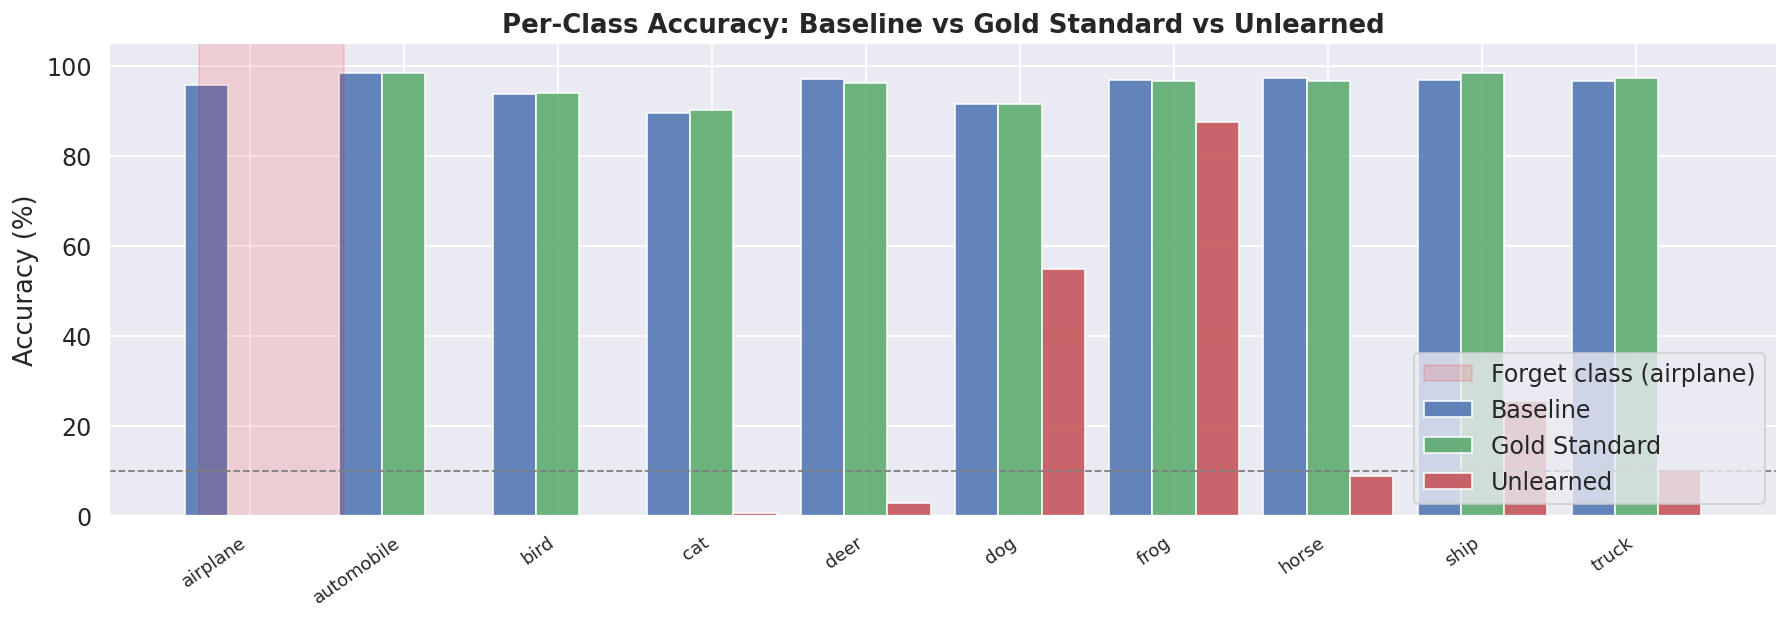

In [11]:
# ============================================================
# CELL 4: Behavioral Evaluation — 3-Model Comparison Table
# ============================================================

# ═════════════════════════════════════════════════════════════
# METRIC FUNCTIONS
# ═════════════════════════════════════════════════════════════

@torch.no_grad()
def get_class_accuracy(model: nn.Module,
                       loader: DataLoader,
                       device: torch.device) -> float:
    """Top-1 accuracy (%) on all samples in `loader`."""
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds    = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / max(total, 1)


@torch.no_grad()
def get_forget_entropy(model: nn.Module,
                       loader: DataLoader,
                       device: torch.device) -> float:
    """
    Mean Shannon entropy (nats) of the model's output distribution
    on forget-class images.

    H(p) = −Σ_k p_k · log(p_k)

    Interpretation:
      Before unlearning : entropy ≈ low   (model is confident & correct)
      After  unlearning : entropy ≈ high  (model is maximally confused)
      Perfect unlearning: H → log(10) ≈ 2.303 nats  (uniform distribution)

    The Gold Standard model has never seen the forget class during training
    so its entropy on forget images is a natural reference point.
    """
    model.eval()
    total_H = count = 0.0
    for imgs, _ in loader:
        imgs  = imgs.to(device)
        probs = F.softmax(model(imgs), dim=1)         # (B, 10)
        # Per-sample entropy: −Σ_k p_k log(p_k)
        entropy = -(probs * (probs + 1e-9).log()).sum(dim=1)  # (B,)
        total_H += entropy.sum().item()
        count   += imgs.size(0)
    return total_H / max(count, 1)


@torch.no_grad()
def get_per_class_accuracy(model: nn.Module,
                           loader: DataLoader,
                           device: torch.device,
                           num_classes: int = NUM_CLASSES) -> dict:
    """Returns a dict {class_idx: accuracy%} for per-class breakdown."""
    model.eval()
    correct = [0] * num_classes
    total   = [0] * num_classes

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        for c in range(num_classes):
            mask         = (labels == c)
            correct[c]  += (preds[mask] == labels[mask]).sum().item()
            total[c]    += mask.sum().item()

    return {c: (100.0 * correct[c] / total[c] if total[c] > 0 else float("nan"))
            for c in range(num_classes)}


# ═════════════════════════════════════════════════════════════
# LOAD ALL THREE MODELS
# ═════════════════════════════════════════════════════════════
def load_model(ckpt_path: str) -> nn.Module:
    m = build_resnet18_cifar().to(device)
    m.load_state_dict(torch.load(ckpt_path, map_location=device))
    m.eval()
    return m

print("[Eval] Loading checkpoints …")
mdl_baseline  = load_model(CKPT_BASELINE)
mdl_gold      = load_model(CKPT_GOLD)
mdl_unlearned = load_model(CKPT_UNLEARNED)

models_info = [
    ("Baseline",     mdl_baseline),
    ("Gold Standard",mdl_gold),
    ("Unlearned",    mdl_unlearned),
]

# ═════════════════════════════════════════════════════════════
# COMPUTE METRICS
# ═════════════════════════════════════════════════════════════
MAX_ENTROPY = math.log(NUM_CLASSES)   # ≈ 2.303 nats (uniform distribution)

results = {}
for name, mdl in models_info:
    print(f"[Eval] Evaluating '{name}' …")
    results[name] = {
        "forget_acc"  : get_class_accuracy(mdl, forget_test_loader, device),
        "retain_acc"  : get_class_accuracy(mdl, retain_test_loader, device),
        "forget_H"    : get_forget_entropy (mdl, forget_test_loader, device),
        "per_class"   : get_per_class_accuracy(mdl, full_test_loader, device),
    }

# ═════════════════════════════════════════════════════════════
# FORMATTED COMPARISON TABLE
# ═════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print(f"  {'BEHAVIORAL EVALUATION TABLE':^68}")
print("═" * 72)
print(f"  {'Metric':<32} {'Baseline':>12} {'Gold Std':>12} {'Unlearned':>12}")
print("─" * 72)

metrics_display = [
    ("Forget Cls Accuracy  (%) ↓", "forget_acc"),
    ("Retain Cls Accuracy  (%) ↑", "retain_acc"),
    ("Forget Cls Entropy (nats) ↑", "forget_H"),
]
for label, key in metrics_display:
    vals = [results[n][key] for n in ["Baseline", "Gold Standard", "Unlearned"]]
    print(f"  {label:<32} {vals[0]:>12.3f} {vals[1]:>12.3f} {vals[2]:>12.3f}")

print("─" * 72)
print(f"  {'Max possible entropy':32} {'':>12} {'':>12} {MAX_ENTROPY:>12.3f}")
print("═" * 72)

# How close is Unlearned to Gold Standard?
delta_forget = abs(results["Unlearned"]["forget_acc"]  - results["Gold Standard"]["forget_acc"])
delta_retain = abs(results["Unlearned"]["retain_acc"]  - results["Gold Standard"]["retain_acc"])
delta_H      = abs(results["Unlearned"]["forget_H"]    - results["Gold Standard"]["forget_H"])
print(f"\n  Gap (Unlearned vs Gold Standard):")
print(f"    Forget accuracy gap : {delta_forget:.2f}%  (lower = better)")
print(f"    Retain accuracy gap : {delta_retain:.2f}%  (lower = better)")
print(f"    Entropy gap         : {delta_H:.4f} nats (lower = better)")

# ═════════════════════════════════════════════════════════════
# PER-CLASS ACCURACY BAR CHART
# ═════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(NUM_CLASSES)
width = 0.28
colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, (name, mdl) in enumerate(models_info):
    accs = [results[name]["per_class"][c] for c in range(NUM_CLASSES)]
    bars = ax.bar(x + i * width, accs, width,
                  label=name, color=colors[i], alpha=0.85, edgecolor="white")

# Highlight the forget class column
ax.axvspan(FORGET_CLASS - 0.05, FORGET_CLASS + 3 * width + 0.05,
           alpha=0.12, color="red", label=f"Forget class ({CLASS_NAMES[FORGET_CLASS]})")

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=10)
ax.set(title="Per-Class Accuracy: Baseline vs Gold Standard vs Unlearned",
       ylabel="Accuracy (%)", ylim=(0, 105))
ax.legend(loc="lower right")
ax.axhline(y=10, color="gray", linestyle="--", lw=1, label="Random chance (10%)")

plt.tight_layout()
plt.savefig("per_class_accuracy_comparison.png", bbox_inches="tight")
plt.show()

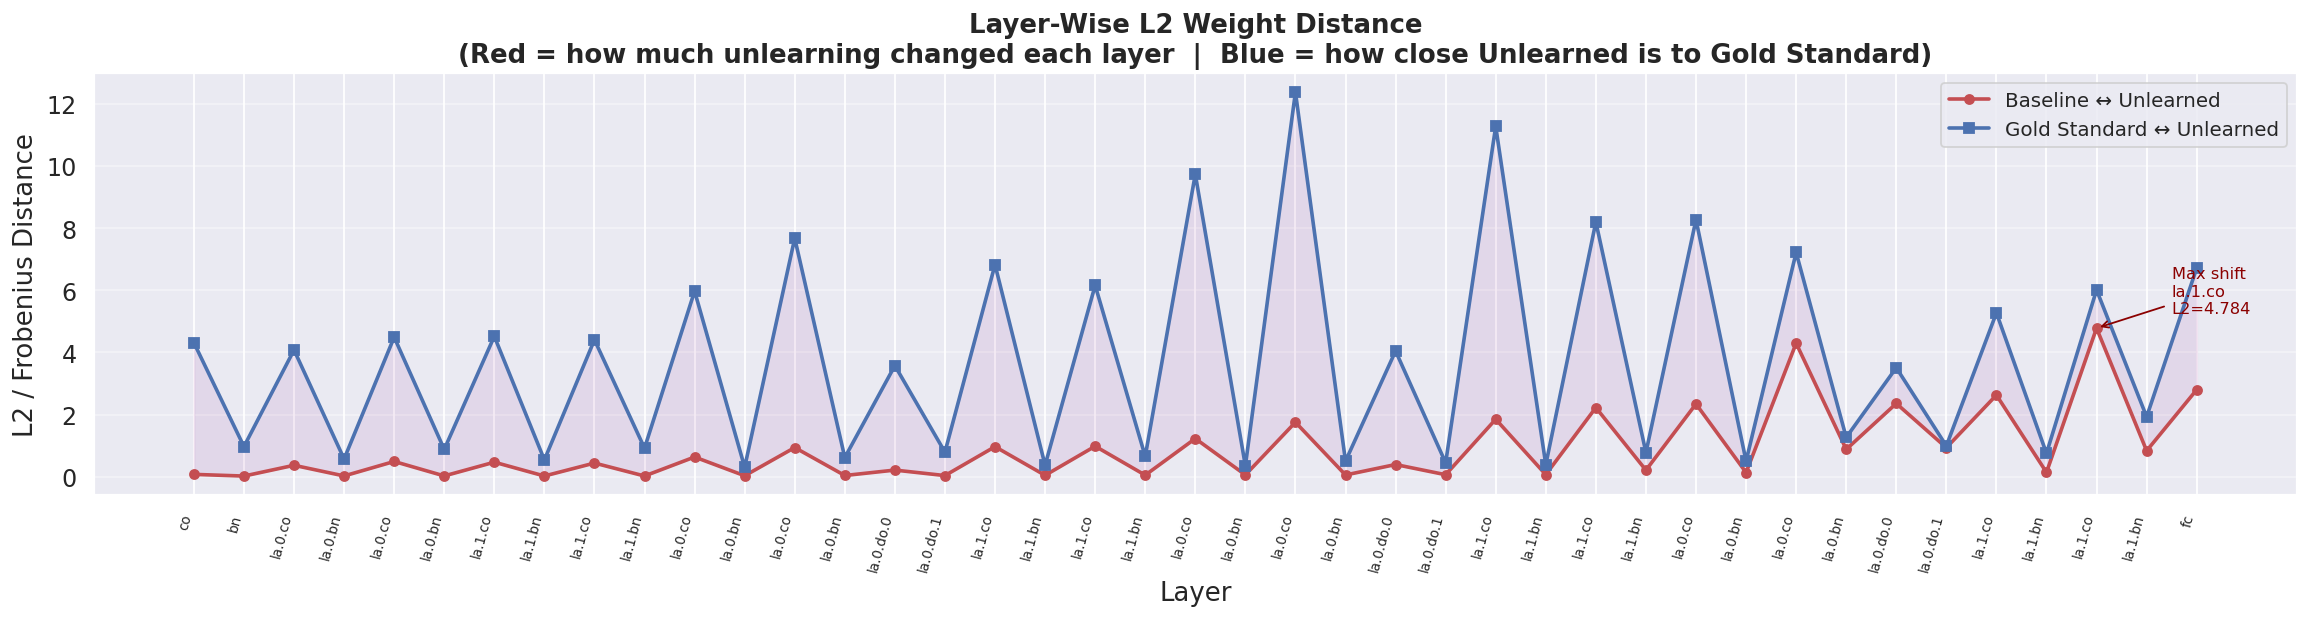


[L2] Top-5 layers most changed by unlearning (Baseline↔Unlearned):
  layer4.1.conv2.weight                               BL↔UL: 4.7835   GS↔UL: 6.0148
  layer4.0.conv2.weight                               BL↔UL: 4.2987   GS↔UL: 7.2217
  fc.weight                                           BL↔UL: 2.8007   GS↔UL: 6.7189
  layer4.1.conv1.weight                               BL↔UL: 2.6283   GS↔UL: 5.2753
  layer4.0.downsample.0.weight                        BL↔UL: 2.3578   GS↔UL: 3.5092
[PCA] Extracting features for all models …


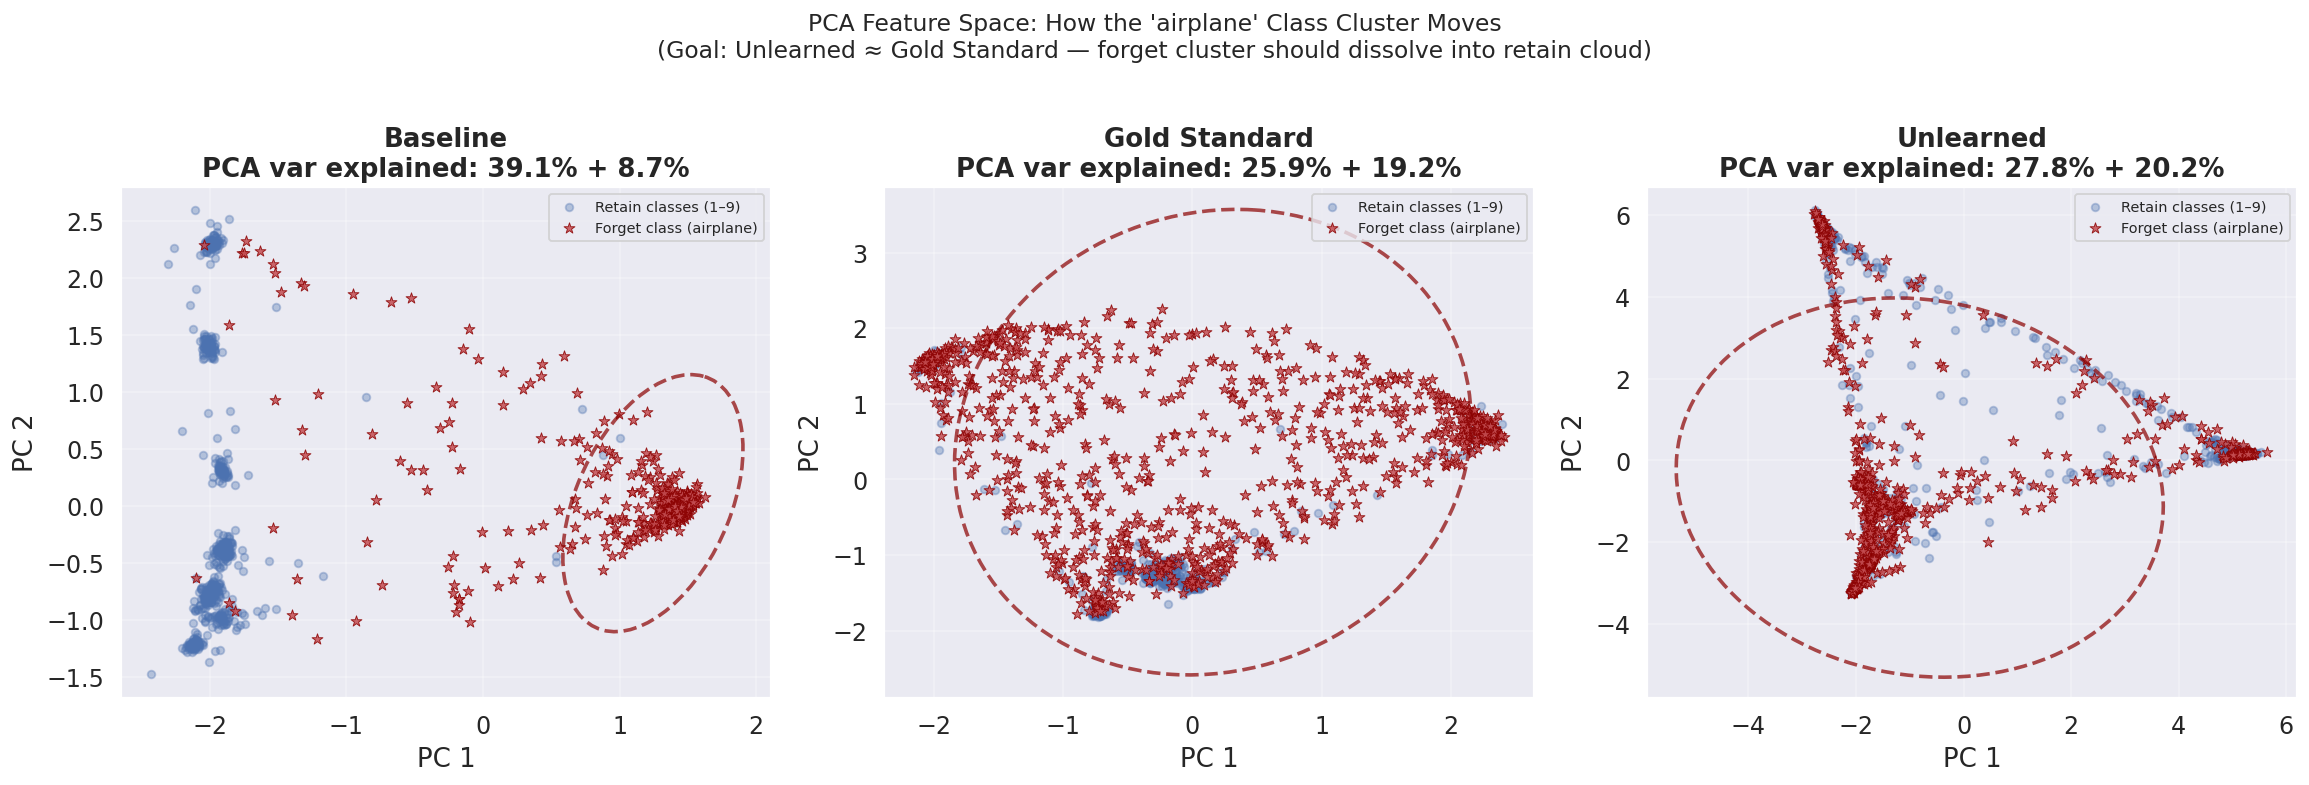

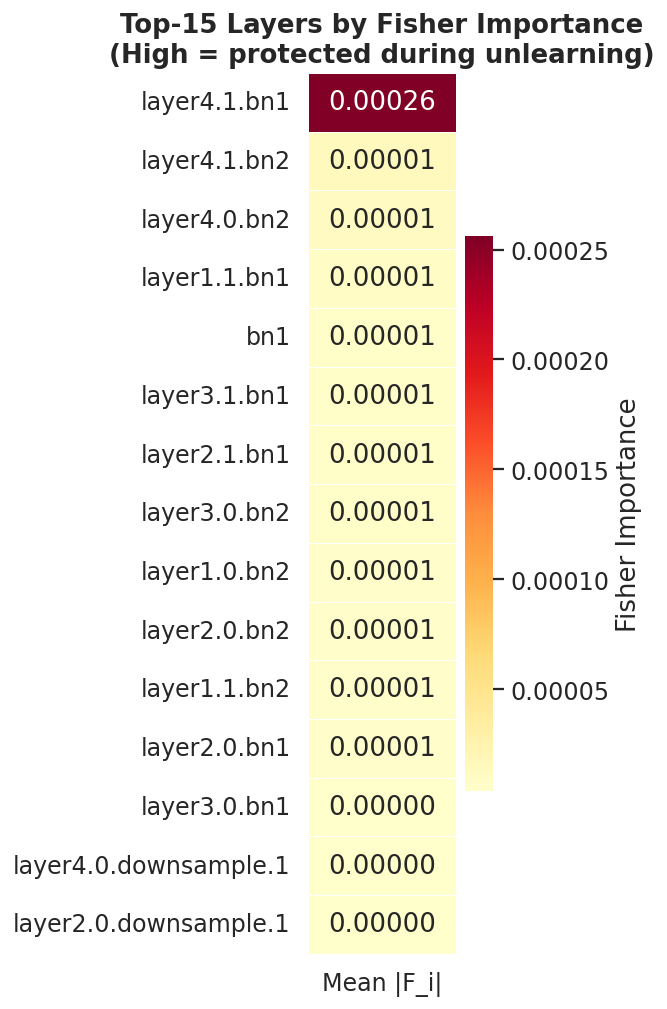


════════════════════════════════════════════════════════════════════════
  FINAL EXPERIMENT SUMMARY
════════════════════════════════════════════════════════════════════════
  Forget class     : 0 — 'airplane'
  Unlearn epochs   : 10
  α / β / λ        : 1.0 / 0.5 / 100.0

  Model                  Forget Acc   Retain Acc      Entropy
  ──────────────────────────────────────────────────────────
  Baseline                   95.60%       95.24%      0.5738
  Gold Standard               0.00%       95.43%      0.8916
  Unlearned                   0.00%       21.13%      0.1385
  (Uniform target)                                    2.3026
════════════════════════════════════════════════════════════════════════

  Saved files:
    ✓ baseline_model.pth
    ✓ gold_standard_model.pth
    ✓ unlearned_model.pth
    ✓ unlearning_loss_components.png
    ✓ per_class_accuracy_comparison.png
    ✓ layerwise_l2_distance.png
    ✓ pca_feature_space.png
    ✓ fisher_heatmap.png


In [12]:
# ============================================================
# CELL 5: Deep Weight Analysis — L2 Layer Distance & PCA
# ============================================================

# ═════════════════════════════════════════════════════════════
# 5-A  LAYER-WISE L2 DISTANCE
# ═════════════════════════════════════════════════════════════
def compute_layerwise_l2(model_a: nn.Module,
                         model_b: nn.Module,
                         label_a: str = "A",
                         label_b: str = "B") -> dict:
    """
    For each named parameter layer, computes the L2 (Frobenius) norm
    of the difference tensor:

        L2_i = ‖ θ_i^A − θ_i^B ‖_F

    A large L2 distance in a layer means the two models differ significantly
    in that layer's learned representations.

    Returns:
        { layer_name → L2 scalar }
    """
    distances = {}
    state_a   = dict(model_a.named_parameters())
    state_b   = dict(model_b.named_parameters())

    with torch.no_grad():
        for name in state_a:
            if name in state_b:
                diff = state_a[name].detach() - state_b[name].detach()
                distances[name] = diff.norm(p="fro").item()

    return distances


def plot_layerwise_l2(model_baseline:  nn.Module,
                      model_gold:       nn.Module,
                      model_unlearned:  nn.Module):
    """
    Plots two L2-distance curves on the same axis:
      • Baseline  vs Unlearned  (red)  — how much did unlearning change each layer?
      • Gold Std  vs Unlearned  (blue) — how close is Unlearned to the ideal?

    Interpretation:
      Layers where Baseline↔Unlearned distance is large but Gold↔Unlearned
      distance is small indicate that unlearning moved the weights toward the
      Gold Standard — exactly what we want.
    """
    dist_bu = compute_layerwise_l2(model_baseline, model_unlearned,
                                   "Baseline", "Unlearned")
    dist_gu = compute_layerwise_l2(model_gold,     model_unlearned,
                                   "Gold Std",     "Unlearned")

    # Use only weight layers (skip biases for clarity)
    weight_layers = [k for k in dist_bu.keys() if "weight" in k]

    # Create short display labels: "layer1.0.conv1.weight" → "L1.0.c1"
    short_labels = []
    for k in weight_layers:
        parts = k.replace(".weight", "").split(".")
        short = ".".join(p[:2] for p in parts)
        short_labels.append(short)

    bu_vals = [dist_bu[k] for k in weight_layers]
    gu_vals = [dist_gu[k] for k in weight_layers]
    x       = np.arange(len(weight_layers))

    fig, ax = plt.subplots(figsize=(18, 5))

    ax.plot(x, bu_vals, color="#C44E52", lw=2, marker="o", ms=5,
            label="Baseline ↔ Unlearned")
    ax.plot(x, gu_vals, color="#4C72B0", lw=2, marker="s", ms=5,
            label="Gold Standard ↔ Unlearned")
    ax.fill_between(x, bu_vals, gu_vals, alpha=0.08, color="purple")

    # Annotate the layer with the largest Baseline↔Unlearned shift
    max_idx = int(np.argmax(bu_vals))
    ax.annotate(
        f"Max shift\n{short_labels[max_idx]}\nL2={bu_vals[max_idx]:.3f}",
        xy=(max_idx, bu_vals[max_idx]),
        xytext=(max_idx + 1.5, bu_vals[max_idx] * 1.1),
        arrowprops=dict(arrowstyle="->", color="darkred"),
        fontsize=9, color="darkred",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=75, ha="right", fontsize=7.5)
    ax.set(title="Layer-Wise L2 Weight Distance\n"
                 "(Red = how much unlearning changed each layer  |  "
                 "Blue = how close Unlearned is to Gold Standard)",
           ylabel="L2 / Frobenius Distance",
           xlabel="Layer")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.savefig("layerwise_l2_distance.png", bbox_inches="tight")
    plt.show()

    # Print top-5 most-changed layers
    top5_changed = sorted(zip(weight_layers, bu_vals), key=lambda x: -x[1])[:5]
    print("\n[L2] Top-5 layers most changed by unlearning (Baseline↔Unlearned):")
    for layer, val in top5_changed:
        gu = dist_gu[layer]
        print(f"  {layer:<50s}  BL↔UL: {val:.4f}   GS↔UL: {gu:.4f}")


# Run L2 analysis
plot_layerwise_l2(mdl_baseline, mdl_gold, mdl_unlearned)


# ═════════════════════════════════════════════════════════════
# 5-B  PCA FEATURE-SPACE ANALYSIS
# ═════════════════════════════════════════════════════════════
def extract_penultimate_features(model:  nn.Module,
                                 loader: DataLoader,
                                 device: torch.device,
                                 max_batches: int = 20) -> np.ndarray:
    """
    Extracts 512-dimensional embeddings from the layer immediately
    before the final classifier (ResNet's avgpool output).

    For ResNet-18, the forward path ends with:
        ... → layer4 → avgpool (512-d) → flatten → fc (10-d)

    We hook into the avgpool output to get the 512-d representation.
    This is the model's internal "concept vector" for each image.

    Uses PyTorch forward hooks — architecture-agnostic approach.
    """
    model.eval()
    features_list = []

    # ── Register a forward hook on the avgpool layer ──────────
    # The hook captures the OUTPUT of avgpool after every forward pass
    hook_output = []

    def hook_fn(module, input, output):
        # avgpool output shape: (B, 512, 1, 1) → flatten to (B, 512)
        hook_output.append(output.detach().flatten(1).cpu())

    handle = model.avgpool.register_forward_hook(hook_fn)

    with torch.no_grad():
        for batch_idx, (imgs, _) in enumerate(loader):
            if batch_idx >= max_batches:
                break
            imgs = imgs.to(device)
            model(imgs)   # forward pass triggers the hook

    handle.remove()   # always remove hooks to avoid memory leaks!

    # Concatenate all batches → (N, 512)
    return torch.cat(hook_output, dim=0).numpy()


def plot_pca_feature_space(models_dict:    dict,
                           forget_loader:  DataLoader,
                           retain_loader:  DataLoader,
                           device:         torch.device,
                           n_retain_batches: int = 5):
    """
    Runs PCA on 512-d embeddings and plots a 2-D scatter for all three models.

    Each subplot shows:
      • Blue dots  — retain-class images (should cluster tightly)
      • Red stars  — forget-class images (should scatter or merge with retain
                     after successful unlearning)

    A well-unlearned model should show forget-class points that look
    SIMILAR to the Gold Standard model (scattered / no distinct cluster).
    The Baseline model should show a clearly separate forget-class cluster.
    """
    print("[PCA] Extracting features for all models …")

    # We need a combined loader for PCA fitting (retain + forget together)
    # so that both point clouds share the same PCA basis
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    model_names = list(models_dict.keys())
    colors_retain = "#4C72B0"
    colors_forget = "#C44E52"

    for ax, name in zip(axes, model_names):
        mdl = models_dict[name]

        # Extract embeddings separately for forget and retain
        feats_forget = extract_penultimate_features(
            mdl, forget_loader, device, max_batches=10)
        feats_retain = extract_penultimate_features(
            mdl, retain_loader, device, max_batches=n_retain_batches)

        # Fit PCA on the COMBINED embedding space (forget + retain)
        combined = np.vstack([feats_retain, feats_forget])
        pca = PCA(n_components=2, random_state=SEED)
        pca.fit(combined)

        retain_2d = pca.transform(feats_retain)
        forget_2d = pca.transform(feats_forget)

        # ── Scatter plot ──────────────────────────────────────
        ax.scatter(retain_2d[:, 0], retain_2d[:, 1],
                   c=colors_retain, alpha=0.35, s=18,
                   label=f"Retain classes (1–9)")

        ax.scatter(forget_2d[:, 0], forget_2d[:, 1],
                   c=colors_forget, alpha=0.85, s=40,
                   marker="*", label=f"Forget class ({CLASS_NAMES[FORGET_CLASS]})",
                   edgecolors="darkred", linewidths=0.5)

        # Draw convex hull ellipse around forget cluster to visualise spread
        if len(forget_2d) > 2:
            from matplotlib.patches import Ellipse
            cov    = np.cov(forget_2d.T)
            eigval, eigvec = np.linalg.eigh(cov)
            angle  = np.degrees(np.arctan2(*eigvec[:, 1][::-1]))
            width, height = 4 * np.sqrt(eigval)   # 2-sigma ellipse
            ellipse = Ellipse(
                xy     = forget_2d.mean(axis=0),
                width  = width, height = height, angle = angle,
                edgecolor="darkred", facecolor="none",
                linewidth=2, linestyle="--", alpha=0.7,
            )
            ax.add_patch(ellipse)

        var_explained = pca.explained_variance_ratio_ * 100
        ax.set(title=f"{name}\n"
                     f"PCA var explained: {var_explained[0]:.1f}% + {var_explained[1]:.1f}%",
               xlabel="PC 1", ylabel="PC 2")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(alpha=0.3)

    plt.suptitle(
        f"PCA Feature Space: How the '{CLASS_NAMES[FORGET_CLASS]}' Class Cluster Moves\n"
        f"(Goal: Unlearned ≈ Gold Standard — forget cluster should dissolve into retain cloud)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig("pca_feature_space.png", bbox_inches="tight")
    plt.show()


# Run PCA analysis
models_for_pca = {
    "Baseline":      mdl_baseline,
    "Gold Standard": mdl_gold,
    "Unlearned":     mdl_unlearned,
}
plot_pca_feature_space(
    models_dict     = models_for_pca,
    forget_loader   = forget_test_loader,
    retain_loader   = retain_test_loader,
    device          = device,
)

# ═════════════════════════════════════════════════════════════
# 5-C  FISHER IMPORTANCE HEATMAP (bonus visualisation)
# ═════════════════════════════════════════════════════════════
def plot_fisher_heatmap(fisher_dict: dict, top_n_layers: int = 15):
    """
    Heatmap of mean Fisher importance per layer.
    Layers with HIGH Fisher values are heavily protected during unlearning.
    This visualises WHICH layers are most critical for retain-class knowledge.
    """
    layer_names = []
    mean_fisher = []

    for name, f_tensor in fisher_dict.items():
        if "weight" in name:   # skip biases for clarity
            layer_names.append(name.replace(".weight", ""))
            mean_fisher.append(f_tensor.mean().item())

    # Sort by importance and take top N
    sorted_pairs = sorted(zip(layer_names, mean_fisher),
                          key=lambda x: -x[1])[:top_n_layers]
    names_sorted, vals_sorted = zip(*sorted_pairs)

    fig, ax = plt.subplots(figsize=(5, 8))
    vals_arr = np.array(vals_sorted).reshape(-1, 1)

    sns.heatmap(
        vals_arr,
        ax          = ax,
        yticklabels = names_sorted,
        xticklabels = ["Mean |F_i|"],
        cmap        = "YlOrRd",
        annot       = True,
        fmt         = ".5f",
        linewidths  = 0.5,
        cbar_kws    = {"label": "Fisher Importance"},
    )
    ax.set(title=f"Top-{top_n_layers} Layers by Fisher Importance\n"
                 f"(High = protected during unlearning)",
           ylabel="")
    plt.tight_layout()
    plt.savefig("fisher_heatmap.png", bbox_inches="tight")
    plt.show()


plot_fisher_heatmap(fisher_dict, top_n_layers=15)

# ═════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═════════════════════════════════════════════════════════════
print("\n" + "═" * 72)
print("  FINAL EXPERIMENT SUMMARY")
print("═" * 72)
print(f"  Forget class     : {FORGET_CLASS} — '{CLASS_NAMES[FORGET_CLASS]}'")
print(f"  Unlearn epochs   : {UNLEARN_EPOCHS}")
print(f"  α / β / λ        : {ALPHA} / {BETA} / {LAMBDA_REG}")
print()
print(f"  {'Model':<20} {'Forget Acc':>12} {'Retain Acc':>12} {'Entropy':>12}")
print("  " + "─" * 58)
for name in ["Baseline", "Gold Standard", "Unlearned"]:
    r = results[name]
    print(f"  {name:<20} {r['forget_acc']:>11.2f}% {r['retain_acc']:>11.2f}% "
          f"{r['forget_H']:>11.4f}")
print(f"  {'(Uniform target)':20} {'':>12} {'':>12} {MAX_ENTROPY:>11.4f}")
print("═" * 72)
print(f"\n  Saved files:")
for f in [CKPT_BASELINE, CKPT_GOLD, CKPT_UNLEARNED,
          "unlearning_loss_components.png",
          "per_class_accuracy_comparison.png",
          "layerwise_l2_distance.png",
          "pca_feature_space.png",
          "fisher_heatmap.png"]:
    print(f"    ✓ {f}")